# PSY 39200 Introduction to Computational Psychology and AI

## Week 14 The Free Energy Principle Theory in Neuroscience

## There are no questions or coding exercises in this tutorial, but please still post a quesiton or comment on Piazza for discussion.

## Please prepare for your project presentation in next week.

## Zhixian Han <br> Department of Psychological Sciences <br> Purdue University







# The Free Energy Principle Theory in Neuroscience

## Hidden markov model

HMM_graphical model.svg

**Figure:** Graphical representation of a Hidden Markov Model (HMM).

The hidden states $x_t$ evolve over time according to the transition matrix $A$ (horizontal arrows), and each hidden state generates an observation $y_t$ (vertical arrows).

First, the brain needs to learn an internal model of the environment. We assume this model is a Hidden Markov Model.

Once the brain has learned a Hidden Markov Model of an environment, the model typically specifies the following probabilities:

$$
p(s_0), \quad p(o_t \mid s_t), \quad p(s_{t+1} \mid s_t)
$$

Where

- $p(s_0)$ is the initial prior probability over hidden states

- $p(o_t \mid s_t)$ is the likelihood or emission probability of getting the observation $o_t$ given the hidden state $s_t$ at time $t$

- $p(s_{t+1} \mid s_t)$ is the hidden state transition probability from the hidden state $s_t$ at time $t$ to the hidden state $s_{t+1}$ at time $t+1$

From these probabilities, the following distributions can be derived from the model:

$$
p(s_t), \quad p(s_t, o_t), \quad p(o_t)
$$

Where

- $p(s_t)$ is the prior belief about the hidden state $s_t$ at time $t$

- $p(s_t, o_t)$ is the joint probability of hidden state and observation at time $t$

- $p(o_t)$ is the marginal probability of getting the observation $o_t$ at time $t$

In addition, the following quantities must be inferred using the model and observations:

$$
p(s \mid o)
$$

Where

- $p(s \mid o)$ is the posterior belief about the hidden state given observations

- Here, $o$ denotes the set of relevant observations, rather than a single observation at time $t$



## **Generative Models vs. Recognition Models in Neuroscience and Psychology**

In neuroscience and psychology, a common idea is that there is a distinction between relatively stable **generative models** and rapidly updated **recognition models**, with the two operating on different timescales.

### **1. Generative models: long-term learned structure**

- The generative model specifies how hidden states generate sensory observations and, in dynamic settings, how hidden states evolve over time.

- This can include both the observation model

  $$
  p(o_t \mid s_t)
  $$

  and the transition model

  $$
  p(s_t \mid s_{t-1})
  $$

- The parameters of the generative model are often assumed to be learned over longer timescales through experience, development, and synaptic plasticity.

- Once learned, they are often treated as relatively stable during moment-to-moment inference.

### **2. Recognition models: fast inference**

- The recognition model represents the system's current beliefs about hidden states given sensory data.

- In variational formulations, this is often written as an approximate posterior, such as

  $$
  q(s)
  \quad \text{or} \quad
  q_\phi(s \mid o)
  $$

  rather than the exact posterior

  $$
  p(s \mid o)
  $$

- These beliefs are updated rapidly as new sensory information arrives.

### **3. Relation to the free energy principle**

- In many free-energy formulations, online inference updates posterior beliefs over hidden states while holding the generative model parameters fixed.

- Over longer timescales, however, the parameters of the generative model can also be updated through learning.

- Therefore, a useful distinction is that **inference is fast**, whereas **learning of the generative model is slower**.

### **Summary**

- Generative and transition models are typically viewed as products of relatively long-term learning.

- Recognition models are better understood as mechanisms for short-term inference.


## Perceptual Inference (Perception as Inference)

Now ignore the state transitions and consider perception at a fixed time $t$. Suppose we have observed an outcome $o_t$.

According to the perception-as-inference framework, the brain is assumed to have an internal generative model $p(o_t, s_t)$, which specifies how hidden states $s_t$ generate observations $o_t$.

### Learning the generative model

Over long timescales, the brain learns a generative model such that the marginal distribution

$$
p(o_t) = \sum_{s_t} p(o_t, s_t)
$$

matches the real-world distribution $p_{\text{real}}(o_t)$.

This can be formalized as minimizing:

$$
\Phi \equiv \text{KL} [ p_{\text{real}}(o_t), p(o_t) ]
$$

Expanding the KL divergence:

$$
\Phi = \sum_{o} p_{\text{real}}(o_t) \log p_{\text{real}}(o_t)
- \sum_{o} p_{\text{real}}(o_t) \log p(o_t)
$$

The first term does not depend on the model and can be ignored. The objective reduces to:

$$
\Phi_0 \equiv - \sum_{o} p_{\text{real}}(o_t) \log p(o_t)
= \mathbb{E}_{p_{\text{real}}}[-\log p(o_t)]
$$

The quantity

$$
-\log p(o_t)
$$

is called the **surprise** of observation $o_t$ under the model.

Thus, learning aims to minimize the **expected surprise** of observations under the model.

### Perception (inference)

Given a learned generative model, perception corresponds to inferring hidden states:

$$
p(s_t \mid o_t)
$$

or an approximate posterior $q(s_t)$.

Therefore:

- **Learning** minimizes expected surprise by adjusting the generative model

- **Perception** performs inference over hidden states given observations  


## Free Energy

### Introducing energy

We define an energy function as:

$$
E(o_t, s_t) \equiv -\log p(o_t, s_t)
$$

This is a reparameterization of probability. It is useful because:

- It converts products into sums:

  $$
  p(o_t, s_t) = p(o_t \mid s_t)p(s_t)
  \Rightarrow
  E(o_t, s_t) = -\log p(o_t \mid s_t) - \log p(s_t)
  $$

- High probability corresponds to low energy  

- Low probability corresponds to high energy  

Using this definition, we can write:

$$
p(o_t, s_t) \propto e^{-E(o_t, s_t)}
$$

---

### Expressing surprise using energy

Substituting energy into the marginal:

$$
p(o_t) = \sum_{s_t}p(o_t, s_t) = \sum_{s_t} e^{-E(o_t, s_t)}
$$

So:

$$
-\log p(o_t) = -\log \left( \sum_{s_t} e^{-E(o_t, s_t)} \right)
$$

This shows that surprise depends on all possible hidden states.

---

### 5. Decomposition of surprise $p(o_t)$



Using Bayes' rule:

$$
p(s_t \mid o_t) = \frac{p(s_t) p(o_t \mid s_t)}{p(o_t)} = \frac{p(o_t, s_t)}{p(o_t)}
$$

$$
p(o_t) = \frac{p(o_t, s_t)}{p(s_t \mid o_t)}
$$

Taking logs:

$$
-\log p(o_t)
= -\log\frac{p(o_t, s_t)}{p(s_t \mid o_t)} = -\log p(o_t, s_t) + \log p(s_t \mid o_t)
$$

Taking expectation under the true posterior $p(s_t \mid o_t)$:

$$
-\log p(o_t)
=
-\mathbb{E}_{p(s_t \mid o_t)}[\log p(o_t, s_t)]
+
\mathbb{E}_{p(s_t \mid o_t)}[\log p(s_t \mid o_t)]
$$

Recognizing that the first term on the right is the negative expected energy $\mathbb{E}_{p(s_t \mid o_t)}[E(o_t, s_t)]$ and the second term on the right is the negative entropy $-H[p(s_t \mid o_t)]$:

$$
-\log p(o_t)
=
\mathbb{E}_{p(s_t \mid o_t)}[E(o_t, s_t)]
-
H[p(s_t \mid o_t)]
$$

This has the form:

$$
-\log p(o_t) = \text{Energy} - \text{Entropy}
$$

It is taking the same mathematical form as the Helmholtz free energy in physics:

$$
\text{Helmholtz free energy } F \equiv U - TS
$$

Where $U$ is internal energy of the system, $T$ is temperature, $S$ is entropy.

Therefore, **the generative surprise $- \log p(o_t)$ also has another name: free energy**.

---



## Variational free energy

In order to minimize surprise, the brain would ideally need to compute the free energy

$$
-\log p(o_t)
$$

However, this quantity is typically intractable to compute directly because it requires marginalizing over hidden states:

$$
p(o_t) = \sum_{s_t} p(o_t, s_t)
$$

or computing using energy and entropy

$$
-\log p(o_t)
=
\mathbb{E}_{p(s_t \mid o_t)}[E(o_t, s_t)]
-
H[p(s_t \mid o_t)]
$$

The brain is assumed to encode an internal generative model with joint distribution $p(o_t, s_t)$, but it does not have explicit access to this distribution.

In addition, the true posterior $p(s_t \mid o_t)$ is generally not directly accessible.

Therefore, we introduce an approximate distribution $q(s_t)$ to derive a tractable upper bound on free energy.

---

### Introducing a variational distribution

We start from:

$$
p(o_t) = \frac{p(o_t,s_t)}{p(s_t|o_t)}
$$

Take negative log at both sides:

$$
-\log p(o_t) = -\log p(o_t,s_t) + \log p(s_t|o_t)
$$

Then introduce a variational distribution $q(s_t)$ to help us find the upper bound:

$$
-\log p(o_t) = -\log p(o_t,s_t) + \log q(s_t) + \log p(s_t|o_t) -
log q(s_t)
= -\log \frac{p(o_t, s_t)}{q(s_t)} + \log \frac{p(s_t \mid o_t)}{q(s_t)}
$$

Taking expectation under $q(s_t)$ on both sides (the left side is independent of $s_t$ so it does not change):

$$
-\log p(o_t)
= - \sum_s q(s_t) \log \frac{p(o_t, s_t)}{q(s_t)}
+ \sum_s q(s_t) \log \frac{p(s_t \mid o_t)}{q(s_t)}
$$

Recognizing that the second term on the right is the negative KL divergence:

$$
\mathrm{KL}\bigl(q(s_t)\,\|\,p(s_t \mid o_t)\bigr)
= \sum_s q(s_t) \log \frac{q(s_t)}{p(s_t \mid o_t)}
$$

we obtain:

$$
-\log p(o_t)
=
-\sum_s q(s_t) \log \frac{p(o_t, s_t)}{q(s_t)}
- \mathrm{KL}\bigl(q(s_t)\,\|\,p(s_t \mid o_t)\bigr)
$$

---

### Variational upper bound

Because KL divergence is always non-negative:

$$
\mathrm{KL}\bigl(q(s_t)\,\|\,p(s_t \mid o_t)\bigr) \ge 0
$$

we have:

$$
-\log p(o_t)
\le
-\sum_s q(s_t) \log \frac{p(o_t, s_t)}{q(s_t)}
$$

Thus, the quantity

$$
F[q]
\equiv
-\sum_s q(s_t) \log \frac{p(o_t, s_t)}{q(s_t)}
$$

is an **upper bound on free energy**, called the **variational free energy**.

---

### Equivalent forms of ariational free energy

The variational free energy can be rewritten as:

$$
F[q]
=
-\sum_s q(s_t) \log p(o_t, s_t)
+
\sum_s q(s_t) \log q(s_t)
$$

or equivalently:

$$
F[q]
=
-\mathbb{E}_{q(s_t)}[\log p(o_t, s_t)]
+
\mathbb{E}_{q(s_t)}[\log q(s_t)]
$$

Using the energy definition $E(o_t, s_t) = -\log p(o_t, s_t)$ and recognizing the second term is the negative entropy of $q(s_t)$:

$$
F[q]
=
\mathbb{E}_{q(s_t)}[E(o_t, s_t)]
-
H[q(s_t)]
$$


This also has the form:

$$
-\log p(o_t) = \text{Energy} - \text{Entropy}
$$

It is taking the same mathematical form as the Helmholtz free energy in physics:

$$
\text{Helmholtz free energy } F \equiv U - TS
$$

Where $U$ is internal energy of the system, $T$ is temperature, $S$ is entropy.

Therefore, this variational upper bound is called **variational free energy**.

---

## Summary

Instead of minimizing free energy $-\log p(o_t)$ directly, which is intractable, the brain is assumed to minimize the **variational free energy**:

$$
F[q] = \mathbb{E}_{q}[E(o_t, s_t)] - H[q]
$$

which provides a tractable upper bound on free energy and becomes exact when $q$ is a very good approximation of the true posterior $p(s_t \mid o_t)$:

$$
q(s_t) = p(s_t \mid o_t)
$$

Therefore, usually people call $F[q]$ **free energy** though it is actually the **variational free energy**.


## **The decomposition of variational free energy**

The variational free energy can be decomposed in different ways.

**One important decomposition is:**

$$
F[q] = - \sum_s q(s_t) \log \frac{ p(o_t,s_t)}{q(s_t)}
$$

Using the rule of conditional probability:

$$
p(o_t, s_t) = p(o_t) p(s_t \mid o_t)
$$

we obtain:

$$
F[q]
= - \sum_s q(s_t) \log \frac{ p(o_t)p(s_t|o_t)}{q(s_t)}
$$

$$
= - \sum_s q(s_t) \log p(o_t)
+ \sum_s q(s_t) \log \frac{q(s_t)}{p(s_t|o_t)}
$$

Since $-\log p(o_t)$ does not depend on $s_t$:

$$
F[q]
= - \log p(o_t)
+ \mathrm{KL}\bigl(q(s_t) \,\|\, p(s_t \mid o_t)\bigr)
$$

---

### Interpretation

This decomposition shows that:

- Variational free energy consists of:
  - the **surprise** $-\log p(o_t)$  
  - plus a **KL divergence term**

- Since KL divergence is always non-negative:

$$
F[q] \ge -\log p(o_t)
$$

Thus, variational free energy is an **upper bound on surprise**.

---

### Role of the approximate posterior

The distribution $q(s_t)$ is called the **approximate posterior**, because it approximates the true posterior $p(s_t \mid o_t)$.

If $q(s_t)$ is close to $p(s_t \mid o_t)$, then:

$$
\mathrm{KL}(q \,\|\, p) \to 0
\quad \Rightarrow \quad
F[q] \to -\log p(o_t)
$$

**Therefore, the brain can minimize variational free energy by learning a better approximate posterior $q(s_t)$ that is very similar to the true posterior $p(s_t|o_t)$.**


## Interpretation of $q(s_t)$ as a persisting belief state

The free energy principle assumes that the approximate posterior $q(s_t)$ represents a **persisting belief state** that is updated continuously as new sensory input arrives.

Rather than being a one-step posterior computation, $q(s_t)$ is **recursively refined over time** through prediction and update steps:

- Before observing new data → $q(s_t)$ is the prior.

- After updating beliefs with new data $o_t$ → $q(s_t)$ approximates the posterior.

- Before the next observation arrives → The updated $q(s_{t+1}) = q(s_t) D$ acts as a prior for future inference. Where $D$ is the state-transition matrix.

The same distribution $q(s_t)$ plays two roles:

- As a **prior**, when it is propagated forward before observing new data  
- As an **approximate posterior**, after incorporating new observations  

Therefore, $q(s_t)$ is best understood as a **dynamically evolving belief state** rather than a static posterior.

In the following derivations, $q(s_t)$ can be used to approximate both the posterior $p(s_t|o_t)$ and the prior $p(s_t)$ depending on the context.


## **The second way of decomposing the variational free energy**

$$
F[q] = - \sum_s q(s_t) \log \frac{ p(o_t,s_t)}{q(s_t)} = - \sum_s q(s_t) \log \frac{ p(s_t)p(o_t|s_t)}{q(s_t)} = - \sum_s q(s_t) \log p(o_t|s_t) + \sum_s q(s_t) \log \frac{q(s_t)}{p(s_t)} \\ = -\mathbb{E}_{q(s_t)}[\log p(o_t|s_t)] + \text{KL}[q(s_t)||p(s_t)]
$$

Where the first term (without the negative sign) is **accuracy**

$$
\mathbb{E}_{q(s_t)}[\log p(o_t|s_t)]
$$

- It measures how well the model explains the observed data.    

- It is higher when the model assigns high probability to observed outcomes under likely hidden states.   

and the second term is **complexity**

$$
\text{KL}[q(s_t)||p(s_t)]
$$

- It quantifies how much the approximate posterior $q(s_t)$ deviates from the prior $p(s_t)$.

- It is higher when posterior beliefs must change substantially from prior expectations.

Therefore, variational free energy is equal to the complexity $\text{KL}[q(s_t)||p(s_t)]$ minus the model accuracy $\mathbb{E}_{q(s_t)}[\log p(o_t|s_t)] $.

As a result, **the brain can minimize variational free energy by learning a better approximate posterior $q(s_t)$ that can increase accuracy $\mathbb{E}_{q(s_t)}[\log p(o_t|s_t)] $ and reduce complexity $\text{KL}[q(s_t)||p(s_t)]$** (i.e. a simple model that works well).

## Active Inference (Planning as Inference)



Active Inference is a theoretical framework that describes how the brain perceives, predicts, and acts in the world.

It can be summarized as **“perception and action as Bayesian inference.”**

- The brain not only passively updates beliefs (as in traditional Bayesian brain theories), but also actively selects actions that minimize free energy (i.e., expected surprise).

- **Perception**: Updating internal beliefs to better explain and predict sensory input.

- **Action**: Changing the external world (through movement or decisions) to bring sensory inputs closer to prior preferences (e.g., if you are hungry, you act to obtain food).

- The brain selects actions by minimizing **expected free energy (EFE)** over future states.



## The expected variational free energy and active inference

The brain not only passively perceives the world, but also actively takes actions to change it. Therefore, we introduce the framework of **active inference**.

Active inference assumes that the brain not only minimizes variational free energy at the current time, but also selects actions that are expected to minimize variational free energy in the future.

---

### Policy-dependent variational free energy

To formalize action selection, we introduce a policy $\pi$. The brain evaluates policies based on the variational free energy induced by the corresponding belief distribution.

The variational free energy under a policy $\pi$ is defined as:

$$
F[q(s_t \mid \pi)]
= - \sum_{s_t} q(s_t \mid \pi) \log \frac{p(o_t, s_t \mid \pi)}{q(s_t \mid \pi)}
$$

---

### Expected variational free energy

When selecting actions, the brain must consider future outcomes. However, future observations $o_t$ are not yet available at the time of decision-making.

Therefore, the brain evaluates policies by computing the **expected variational free energy** over possible future outcomes:

$$
- \sum_{s_t} q(s_t|\pi) \mathbb{E}_{p(o_t|s_t)}\left[\log \frac{ p(o_t,s_t|\pi)}{q(s_t|\pi)}
\right]
$$

Expanding this expectation:

$$
= - \sum_{o_t,s_t} p(o_t|s_t)\, q(s_t|\pi)
\log \frac{ p(o_t,s_t|\pi)}{q(s_t|\pi)}
$$

---

### Conditional independence assumption

Under the Hidden Markov Model, observations are conditionally independent of the policy given the hidden state:

$$
p(o_t \mid s_t, \pi) = p(o_t \mid s_t)
$$

Therefore, while the policy influences future states, the likelihood mapping from states to observations does not directly depend on the policy.

---

### Interpretation

The brain selects actions by choosing policies that minimize expected variational free energy. This allows the agent to:

- predict future outcomes  
- evaluate their consequences  
- select actions that are expected to reduce variational free energy over time   

## Decomposing the expected variational free energy

We can decompose the expected variational free energy to better understand its components.

We begin with the expected variational free energy we derived above:

$$
-\sum_{o_t,s_t} p(o_t \mid s_t)\, q(s_t \mid \pi)
\log \frac{p(o_t, s_t \mid \pi)}{q(s_t \mid \pi)}
$$

Using

$$
p(o_t, s_t \mid \pi) = p(o_t \mid \pi)\, p(s_t \mid o_t, \pi)
$$

we obtain

$$
-\sum_{o_t,s_t} p(o_t \mid s_t)\, q(s_t \mid \pi)
\log \frac{p(o_t, s_t \mid \pi)}{q(s_t \mid \pi)} \\= -\sum_{o_t,s_t} p(o_t \mid s_t)\, q(s_t \mid \pi)
\log \frac{p(o_t \mid \pi)\, p(s_t \mid o_t, \pi)}{q(s_t \mid \pi)}
$$

$$
=
-\sum_{o_t,s_t} p(o_t \mid s_t)\, q(s_t \mid \pi)\log p(o_t \mid \pi)
-\sum_{o_t,s_t} p(o_t \mid s_t)\, q(s_t \mid \pi)\log \frac{p(s_t \mid o_t, \pi)}{q(s_t \mid \pi)}
$$

Previously, when discussing perception as inference, we assumed that the brain passively receives an observation $o_t$ at time $t$ and updates its beliefs accordingly. However, in active inference, the agent can act on the world and thereby influence future observations.

Therefore, when selecting actions, the agent is not guided only by the predicted outcome distribution $p(o_t \mid \pi)$. Instead, it also takes into account a distribution over preferred outcomes.

The brain is assumed to have different preferences over different possible observations. It assigns high prior probability to observations it prefers and low prior probability to observations it does not prefer. This preference distribution is called the **prior preference** $p^*(o_t)$.

In active inference, policies are evaluated not only in terms of the outcomes they are predicted to generate, but also in terms of how well those predicted outcomes align with the prior preference distribution $p^*(o_t)$.

In this way, the brain does not only reduce free energy by updating its internal beliefs, but can also act to make future observations more consistent with its prior preferences.

Therefore, we define the expected variational free energy for active inference as:

$$
G(\pi)
=
-\sum_{o_t,s_t} p(o_t \mid s_t)\, q(s_t \mid \pi)\log p^*(o_t)
-\sum_{o_t,s_t} p(o_t \mid s_t)\, q(s_t \mid \pi)\log \frac{p(s_t \mid o_t, \pi)}{q(s_t \mid \pi)}
$$

Then the first term (without the minus sign) is called the **extrinsic value** (or **pragmatic value**):

$$
\text{extrinsic value}
=
\sum_{o_t,s_t} p(o_t \mid s_t)\, q(s_t \mid \pi)\log p^*(o_t)
=
\mathbb{E}_{q(o_t,s_t \mid \pi)}[\log p^*(o_t)]
$$

Where $$ q(o_t, s_t \mid \pi) = p(o_t \mid s_t)\, q(s_t \mid \pi) $$

Equivalently,

$$
\text{extrinsic value} = \mathbb{E}_{q(o_t,s_t \mid \pi)}[\log p^*(o_t)]
=
\mathbb{E}_{q(o_t \mid \pi)}[\log p^*(o_t)]
\\=
-\mathrm{H}\bigl(q(o_t \mid \pi), p^*(o_t)\bigr)
$$

where $\mathrm{H}(q, p^*)$ is the cross-entropy between $q(o_t \mid \pi)$ and $p^*(o_t)$.

Therefore, maximizing extrinsic value is equivalent to minimizing the cross-entropy between predicted outcomes and preferred outcomes. In other words, it encourages the agent to choose policies whose predicted outcomes place high probability on preferred observations.

The second term (without the minus sign) is called the **intrinsic value** (or **epistemic value**):

$$
\text{intrinsic value}
=
\sum_{o_t,s_t} p(o_t \mid s_t)\, q(s_t \mid \pi)
\log \frac{p(s_t \mid o_t, \pi)}{q(s_t \mid \pi)}
$$

$$
=
\sum_{o_t,s_t} q(o_t, s_t \mid \pi)
\log \frac{p(s_t \mid o_t, \pi)}{q(s_t \mid \pi)}
$$

Using

$$
q(o_t, s_t \mid \pi) = p(o_t \mid s_t)\, q(s_t \mid \pi) = p(s_t \mid o_t, \pi)\, q(o_t \mid \pi)
$$

we get

$$
\text{intrinsic value}
=
\sum_{o_t,s_t} q(o_t \mid \pi)\, p(s_t \mid o_t, \pi)
\log \frac{p(s_t \mid o_t, \pi)}{q(s_t \mid \pi)}
$$

$$
=
\sum_{o_t} q(o_t \mid \pi)\,
\mathrm{KL}\bigl(p(s_t \mid o_t, \pi)\,\|\,q(s_t \mid \pi)\bigr)
$$

$$
=
\mathbb{E}_{q(o_t \mid \pi)}
\left[
\mathrm{KL}\bigl(p(s_t \mid o_t, \pi)\,\|\,q(s_t \mid \pi)\bigr)
\right]
$$

This term quantifies expected information gain. The agent weighs the information gain

$$
\mathrm{KL}\bigl(p(s_t \mid o_t, \pi)\,\|\,q(s_t \mid \pi)\bigr)
$$

for different possible observations $o_t$ according to the predicted outcome distribution $q(o_t \mid \pi)$.

- If intrinsic value is high, the policy is expected to generate observations that substantially update beliefs about hidden states.
- If intrinsic value is low, the policy is not expected to generate observations that provide much new information.

Therefore, expected variational free energy balances two components:

- **extrinsic value**, which favors preferred outcomes
- **intrinsic value**, which favors informative outcomes  


## Understanding the intrinsic (epistemic) value

We can express intrinsic value in another way to better understand its meaning.

According to Bayes' rule:

$$
p(s_t \mid o_t, \pi)
=
\frac{p(s_t \mid \pi)\, p(o_t \mid s_t)}{p(o_t \mid \pi)}
$$

In practice, these distributions are not directly accessible, so we approximate them using variational distributions:

$$
p(s_t \mid \pi) \approx q(s_t \mid \pi), \quad
p(o_t \mid \pi) \approx q(o_t \mid \pi).
$$

Using these approximations, we can rewrite intrinsic value as:

$$
\text{intrinsic value}
=
\sum_{o_t,s_t} p(o_t \mid s_t)\, q(s_t \mid \pi)
\log \frac{p(s_t \mid o_t, \pi)}{q(s_t \mid \pi)}
\\= \sum_{o_t,s_t} p(o_t \mid s_t)\, q(s_t \mid \pi)
\log \frac{p(s_t \mid \pi)\, p(o_t \mid s_t)}{q(s_t \mid \pi)\, p(o_t \mid \pi)}
$$

$$
\approx
\sum_{o_t,s_t} p(o_t \mid s_t)\, q(s_t \mid \pi)
\log \frac{p(s_t \mid \pi)\, p(o_t \mid s_t)}{p(s_t \mid \pi)\, p(o_t \mid \pi)}
$$

$$
=
\sum_{o_t,s_t} p(o_t,s_t \mid \pi)
\log \frac{p(o_t,s_t \mid \pi)}{p(o_t \mid \pi)\, p(s_t \mid \pi)}
$$

This is the **mutual information** between outcome $O_t$ and hidden state $S_t$ under policy $\pi$:

$$
\text{intrinsic value}
\approx
\sum_{o_t,s_t} p(o_t,s_t \mid \pi)
\log \frac{p(o_t,s_t \mid \pi)}{p(o_t \mid \pi)\, p(s_t \mid \pi)}
= \mathrm{MI}[O_t; S_t \mid \pi]
$$

---

### Interpretation

The mutual information can also be written as:

$$
\mathrm{MI}[O_t; S_t \mid \pi]
=
\mathrm{H}(S_t \mid \pi)
-
\mathrm{H}(S_t \mid O_t, \pi)
$$

This shows that intrinsic value measures how much uncertainty about hidden states is reduced by observing outcomes.

- If the hidden state is already certain (low entropy $\mathrm{H}(S_t \mid \pi)$), intrinsic value is low.
- If the hidden state is uncertain ($\mathrm{H}(S_t \mid \pi)$ is high) but observations are informative ($\mathrm{H}(S_t \mid O_t, \pi)$ is low), intrinsic value is high.

---

## Intuition

Intrinsic value quantifies how much information about hidden states can be gained from observations under a policy.

- High intrinsic value → informative observations → encourages exploration  
- Low intrinsic value → uninformative observations → discourages exploration  

Therefore, **intrinsic value naturally drives curiosity and exploration**.


## Another way of decomposing the expected variational free energy

We can decompose expected variational free energy into interpretable components in another way.

Starting from the expected variational free energy:

$$
G(\pi)
=
-\sum_{o_t,s_t}
p(o_t|s_t)\, q(s_t|\pi)
\log \frac{p^*(o_t,s_t|\pi)}{q(s_t|\pi)}
$$

We define a preference-weighted model:

$$
p^*(o_t,s_t|\pi)
=
p^*(o_t)\, p(s_t|o_t,\pi)
$$

Using this, we obtain:

$$
G(\pi)
=
-\sum_{o_t,s_t}
p(o_t|s_t)\, q(s_t|\pi)
\log \frac{p^*(o_t)\, p(s_t|o_t,\pi)}{q(s_t|\pi)}
$$

We approximate the posterior using variational inference:

$$
p(s_t|o_t,\pi)
= \frac{p(s_t|\pi)\, p(o_t|s_t)}{p(o_t|\pi)}
\approx
\frac{q(s_t|\pi)\, p(o_t|s_t)}{q(o_t|\pi)}
$$

Substituting into $G(\pi)$:

$$
G(\pi)
\approx -\sum_{o_t,s_t}
p(o_t|s_t)\, q(s_t|\pi)
\log \frac{p^*(o_t)\ q(s_t|\pi)\, p(o_t|s_t)}{q(s_t|\pi)\, q(o_t|\pi)}
\\=
-\sum_{o_t,s_t}
p(o_t|s_t)\, q(s_t|\pi)
\log \frac{p^*(o_t)\, p(o_t|s_t)}{q(o_t|\pi)}
$$

Splitting terms and simplify:

$$
G(\pi) =
-\sum_{o_t,s_t}
p(o_t|s_t)\, q(s_t|\pi)
\log \frac{p^*(o_t)}{q(o_t|\pi)}
-\sum_{o_t,s_t}
p(o_t|s_t)\, q(s_t|\pi)
\log p(o_t|s_t)
$$

Define:

$$
q(o_t|\pi)
=
\sum_{s_t} p(o_t|s_t)\, q(s_t|\pi)
$$

Then:

$$
G(\pi)
=
-\sum_{o_t} q(o_t|\pi)\log \frac{p^*(o_t)}{q(o_t|\pi)}
+
\sum_{s_t} q(s_t|\pi)\, H[p(o_t|s_t)]
$$

$$
=
\mathrm{KL}[q(o_t|\pi)\,\|\,p^*(o_t)]
+
\mathbb{E}_{q(s_t|\pi)}[H[p(o_t|s_t)]]
$$  

---

### Interpretation

The expected free energy can be decomposed into two components:

### Expected cost (or expected risk) — extrinsic term

$$
\text{expected cost} = \mathrm{KL}[q(o_t|\pi)\,\|\,p^*(o_t)]
$$

- It quantifies the mismatch between the predicted distribution of outcomes under policy $\pi$, $q(o_t|\pi)$, and the preferred outcome distribution $p^*(o_t)$.

- If a policy leads to predicted outcomes that are close to the preferred outcomes, the expected cost is low. Otherwise, the expected cost is high.

- Therefore, minimizing expected cost encourages the agent to select policies that lead to preferred observations.

---

### Expected ambiguity — intrinsic term

$$
\text{expected ambiguity} = \mathbb{E}_{q(s_t|\pi)}[H[p(o_t|s_t)]]
$$

- It quantifies the expected uncertainty in observations given hidden states under policy $\pi$.

- Ambiguity is high when the likelihood $p(o_t|s_t)$ has high entropy (i.e., observations are noisy or uninformative about the state).

- Ambiguity is low when observations are reliable indicators of hidden states.

- Therefore, minimizing ambiguity encourages the agent to select policies that lead to more informative and less noisy observations.

---

### Summary

- The **expected cost (risk)** term encourages achieving preferred outcomes.  

- The **expected ambiguity** term encourages obtaining reliable, informative observations.  

Together, these terms guide the agent to select actions that both:

- align with its preferences, and  

- reduce uncertainty about the world.

## A Very Simple Example of Applying the Free Energy Principle Theory to Select Policy

Now let us implement a very simple example.

Suppose the environment has only 3 hidden states $s$:  
- "0": empty stomach  
- "1": full  
- "2": over-full  

There are also 3 possible observations $o$:  
- "0": feeling hungry  
- "1": feeling fed  
- "2": feeling over-fed  

Suppose we have learned a generative model $p(o,s)$.

The likelihood (called the A matrix) $p(o \mid s)$ maps hidden states to observations. For example, if your stomach is full, you are likely to feel fed.

The transition probability

$$
p(s_t \mid s_{t-1}, a)
$$

maps the previous state to the next state given an action. Since transitions depend on the action $a$, we can represent them using a separate transition matrix (B matrix) for each action.

Suppose we have two possible actions:

- $a_0$: eat  
- $a_1$: do nothing  

If we eat, the stomach state tends to increase (e.g., from empty to full).  
If we do nothing, the stomach state tends to decrease (e.g., from full to empty).

Finally, we specify prior preferences over observations:

$$
p^*(o_t)
$$

We prefer to feel fed (state "1"), and assign lower probability to feeling hungry ("0") or over-fed ("2").

Thus, preferences are expressed as a probability distribution over observations.

---

Now we can implement a policy selection process based on expected free energy to keep the agent in a preferred state.

### Set up the hidden markov model

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# ============================================
# 1) Generative Model: 3 hidden states, 3 observations
# ============================================
# States: s=0="empty", s=1="full", s=2="over-full"
# Observations: o=0="hungry", o=1="fed", o=2="over-fed"

A = np.array([
    [0.70, 0.20, 0.10],  # s=0 => mostly "hungry"
    [0.10, 0.70, 0.20],  # s=1 => mostly "fed"
    [0.10, 0.20, 0.70]   # s=2 => mostly "over-fed"
])
# A[s, o] = p(o | s)

B1 = np.array([
    [0.1, 0.0, 0.0],  # s_next=0
    [0.8, 0.1, 0.0],  # s_next=1
    [0.1, 0.9, 1.0]   # s_next=2
])
# B1 => transitions if action=0 ("eat")

B2 = np.array([
    [1.0, 0.5, 0.2],  # s_next=0
    [0.0, 0.5, 0.3],  # s_next=1
    [0.0, 0.0, 0.5]   # s_next=2
])
# B2 => transitions if action=1 ("do nothing")

# Preferences over observations (fed > over-fed > hungry)
p_o_pref = np.array([0.05, 0.70, 0.25])


### Prepare untility functions

In [2]:

# ============================================
# 2) Utility Functions
# ============================================
def normalize(p):
    return p / p.sum()

def kl_divergence(q, p):
    mask = (q > 1e-16)
    return np.sum(q[mask] * np.log(q[mask]/p[mask]))

def entropy(p):
    mask = (p > 1e-16)
    return -np.sum(p[mask] * np.log(p[mask]))

def calc_expected_free_energy(q_s, A, p_o_pref):
    """
    Single-step Expected Free Energy:
      G = ∑_s q_s(s)*KL( p(o|s)|| p_o_pref ) + ∑_s q_s(s)*H( p(o|s) )
      = KL( q(o)|| p_o_pref ) + ∑_s q_s(s)*H( p(o|s) )
    """
    q_o = q_s @ A
    q_o = normalize(q_o)
    # Preference mismatch
    term1 = kl_divergence(q_o, p_o_pref)
    # Ambiguity
    term2 = np.sum([q_s[s] * entropy(A[s]) for s in range(len(q_s))])
    return term1 + term2

def softmax_over_policies(energy, beta):
    """
    q(pi) ∝ exp(-beta * energy)
    """
    ex = np.exp(-beta*energy)
    return ex / ex.sum()

def predict_next_belief(q_s, action):
    """
    One-step predictive update from q_s under chosen action (no new observation).
    """
    if action == 0:
        q_s_next = B1 @ q_s
    else:
        q_s_next = B2 @ q_s
    return normalize(q_s_next)

### Set up the environment

In [3]:

# ============================================
# 3) Environment Step (stochastic simulator)
# ============================================
def env_step(env_s, action):
    """
    - Sample env_s_next from B1/B2 given env_s, action
    - Then sample obs from A[env_s_next]
    """
    if action == 0:  # eat
        p_next = B1[:, env_s]
    else:            # do nothing
        p_next = B2[:, env_s]
    env_s_next = np.random.choice([0,1,2], p=p_next)

    p_obs = A[env_s_next,:]
    obs = np.random.choice([0,1,2], p=p_obs)
    return env_s_next, obs

# ============================================
# 4) Enumerate all H-step (3-step) policies
# ============================================
all_policies = []
for a1 in [0,1]:
    for a2 in [0,1]:
        for a3 in [0,1]:
            all_policies.append([a1,a2,a3])
policy_labels = [str(pol) for pol in all_policies]

### Run simulations and visualize the results

Initial env state (unknown to agent): 0


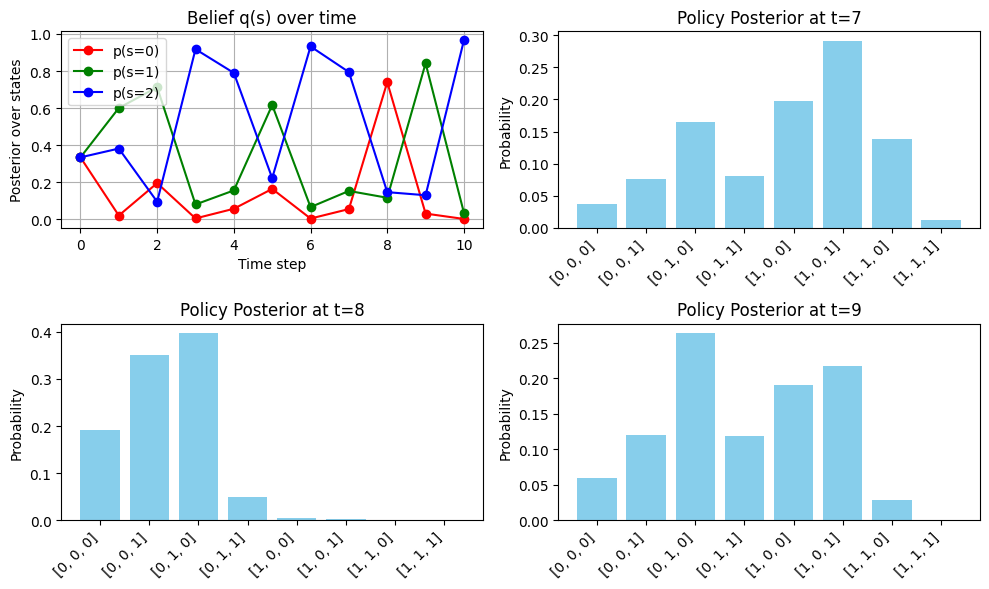


Actions chosen (0=eat, 1=do nothing): [0, 1, 0, 1, 1, 0, 1, 1, 0, 0]
Observations (0=hungry, 1=fed, 2=over-fed): [np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(0), np.int64(1), np.int64(2)]


In [4]:

env_s = 0  # real environment's hidden state at t = 0

np.random.seed(0)

# ============================================
# 5) Closed-Loop Active Inference
# ============================================

# Number of future steps to plan at each iteration
H = 3  # 3-step horizon => 2^3 = 8 possible policies

discount_factor = 0.80

# Softmax precision
beta = 5.0

T = 10  # number of real time steps

# Initial belief over hidden states (agent does not know the true state)
q_s = np.array([1/3, 1/3, 1/3], dtype=float)

print("Initial env state (unknown to agent):", env_s)

actions_chosen = []
observations_seen = []
belief_history = [q_s.copy()]

# Store posterior over policies at each real time step
policy_probs_history = []

for t in range(T):
    # (A) Evaluate each H-step policy from the current belief state
    expected_free_energy = []

    for pol in all_policies:
        q_s_fut = q_s.copy()
        G_total = 0.0

        for step in range(H):
            a_ = pol[step]

            # Predict next hidden-state belief under this action
            q_s_fut = predict_next_belief(q_s_fut, a_)

            # Accumulate discounted expected free energy
            G_total += (discount_factor ** step) * calc_expected_free_energy(
                q_s_fut, A, p_o_pref
            )

        expected_free_energy.append(G_total)

    expected_free_energy = np.array(expected_free_energy)

    # (B) Softmax => posterior over candidate policies
    policy_probs = softmax_over_policies(expected_free_energy, beta)
    policy_probs_history.append(policy_probs)

    # (C) Select the best policy and execute only its first action
    best_policy_idx = np.argmin(expected_free_energy)
    best_policy = all_policies[best_policy_idx]
    action = best_policy[0]
    actions_chosen.append(action)

    # (D) Environment evolves and returns an observation
    env_s, obs = env_step(env_s, action)
    observations_seen.append(obs)

    # (E) Bayesian state estimation:
    #     prior prediction under chosen action
    q_s_pred = predict_next_belief(q_s, action)

    #     posterior update using the new observation
    unnorm = q_s_pred * A[:, obs]
    q_s = normalize(unnorm)

    belief_history.append(q_s.copy())

# ============================================
# 6) Visualization
# ============================================
# (1) Show how the posterior over hidden states evolves
belief_history = np.array(belief_history)  # shape (T+1,3)
time_axis = np.arange(T+1)

plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
plt.plot(time_axis, belief_history[:,0], 'r-o', label='p(s=0)')
plt.plot(time_axis, belief_history[:,1], 'g-o', label='p(s=1)')
plt.plot(time_axis, belief_history[:,2], 'b-o', label='p(s=2)')
plt.xlabel("Time step")
plt.ylabel("Posterior over states")
plt.title("Belief q(s) over time")
plt.legend()
plt.grid(True)

# (2) Show the policy posterior at t = 7 as a bar chart
final_policy_probs = policy_probs_history[7]
plt.subplot(2,2,2)
plt.bar(np.arange(len(final_policy_probs)), final_policy_probs, color='skyblue')
plt.xticks(np.arange(len(final_policy_probs)), policy_labels, rotation=45, ha='right')
plt.ylabel("Probability")
plt.title("Policy Posterior at t={}".format(7))
plt.tight_layout()

# (3) Show the policy posterior at t = 8 as a bar chart
final_policy_probs = policy_probs_history[8]
plt.subplot(2,2,3)
plt.bar(np.arange(len(final_policy_probs)), final_policy_probs, color='skyblue')
plt.xticks(np.arange(len(final_policy_probs)), policy_labels, rotation=45, ha='right')
plt.ylabel("Probability")
plt.title("Policy Posterior at t={}".format(8))
plt.tight_layout()

# (4) Show the policy posterior at t = 9 as a bar chart
final_policy_probs = policy_probs_history[9]
plt.subplot(2,2,4)
plt.bar(np.arange(len(final_policy_probs)), final_policy_probs, color='skyblue')
plt.xticks(np.arange(len(final_policy_probs)), policy_labels, rotation=45, ha='right')
plt.ylabel("Probability")
plt.title("Policy Posterior at t={}".format(9))
plt.tight_layout()
plt.show()

print("\nActions chosen (0=eat, 1=do nothing):", actions_chosen)
print("Observations (0=hungry, 1=fed, 2=over-fed):", observations_seen)
